<a href="https://colab.research.google.com/github/Ashton94089/Actuarial-Practice/blob/main/Medical_Cost_Personal_Datasets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mirichoi0218/insurance")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'insurance' dataset.
Path to dataset files: /kaggle/input/insurance


In [2]:
import os
import pandas as pd
import sqlite3

# 1. 找出下載資料夾裡面的 CSV 檔案名稱
csv_file = os.path.join(path, "insurance.csv")

# 2. 用 Pandas 讀取 CSV
df = pd.read_csv(csv_file)
print("=== 成功讀取 Kaggle 資料集 ===")
print(df.head())

# 3. 匯入 SQLite 資料庫 (接續你的 SQL 練習)
conn = sqlite3.connect(':memory:')
df.to_sql('medical_policies', conn, index=False, if_exists='replace')

print("\n資料已順利寫入 SQL 資料表 `medical_policies`！")

=== 成功讀取 Kaggle 資料集 ===
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

資料已順利寫入 SQL 資料表 `medical_policies`！


In [3]:
sql_extract_data = """
SELECT
    age,
    sex,
    bmi,
    children,
    smoker,
    region,
    charges AS claim_amount,
    CASE WHEN smoker = 'yes' THEN 1 ELSE 0 END AS is_smoker,
    CASE WHEN bmi >= 30.0 THEN 1 ELSE 0 END AS is_obese
FROM
    medical_policies
WHERE
    charges > 0;
"""

In [4]:
# 執行 SQL 語法，把結果載入為 df_glm_input
df_glm_input = pd.read_sql(sql_extract_data, conn)

print("=== SQL 撈取並特徵轉換後的資料前 5 筆 ===")
print(df_glm_input.head())

=== SQL 撈取並特徵轉換後的資料前 5 筆 ===
   age     sex     bmi  children smoker     region  claim_amount  is_smoker  \
0   19  female  27.900         0    yes  southwest   16884.92400          1   
1   18    male  33.770         1     no  southeast    1725.55230          0   
2   28    male  33.000         3     no  southeast    4449.46200          0   
3   33    male  22.705         0     no  northwest   21984.47061          0   
4   32    male  28.880         0     no  northwest    3866.85520          0   

   is_obese  
0         0  
1         1  
2         1  
3         0  
4         0  


EDA 視覺化分析

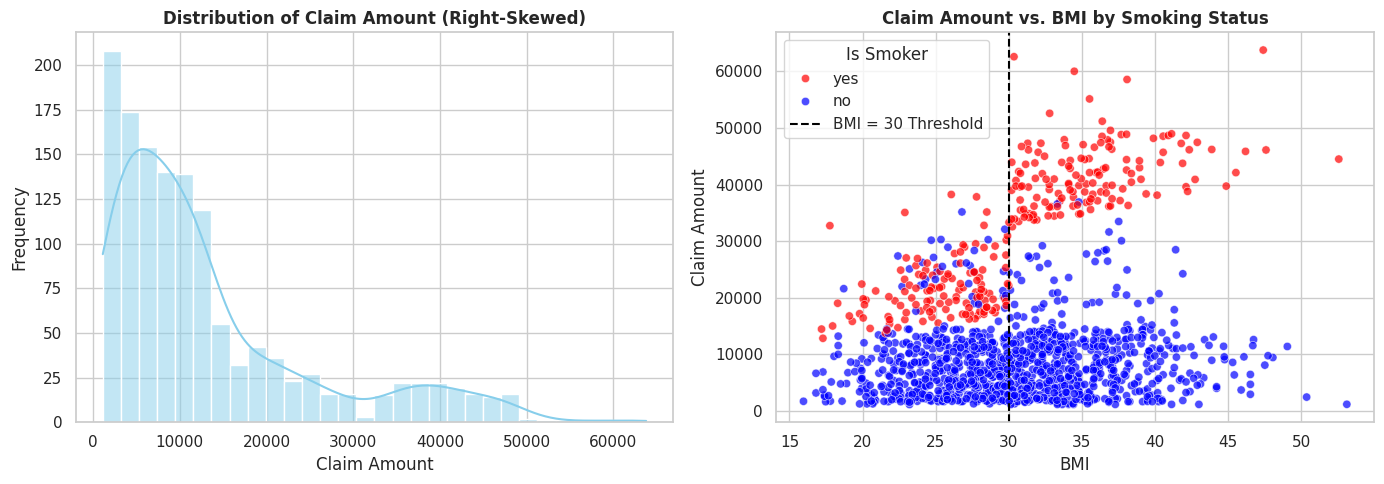

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 設定繪圖風格
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial']
plt.figure(figsize=(14, 5))

# (1) 理賠金額分佈圖 (呈現右偏)
plt.subplot(1, 2, 1)
sns.histplot(df_glm_input['claim_amount'], kde=True, color='skyblue', bins=30)
plt.title('Distribution of Claim Amount (Right-Skewed)', fontsize=12, fontweight='bold')
plt.xlabel('Claim Amount')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.scatterplot(data=df_glm_input, x='bmi', y='claim_amount', hue='smoker', palette={'no': 'blue', 'yes': 'red'}, alpha=0.7)
plt.axvline(x=30, color='black', linestyle='--', label='BMI = 30 Threshold')
plt.title('Claim Amount vs. BMI by Smoking Status', fontsize=12, fontweight='bold')
plt.xlabel('BMI')
plt.ylabel('Claim Amount')
plt.legend(title='Is Smoker')

plt.tight_layout()
plt.show()

Gamma GLM 模型

In [17]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# 建立 Gamma GLM 模型 (使用 Log 連結函數)
# 公式：理賠金額 ~ 年齡 + BMI + 是否抽菸 + 子女數 + 地區
formula = 'claim_amount ~ age + bmi + is_smoker + children + C(region)'

model_gamma = smf.glm(
    formula=formula,
    data=df_glm_input,
    family=sm.families.Gamma(link=sm.families.links.Log())
).fit()

print("\n=== Gamma GLM 模型擬合係數摘要 ===")
print(model_gamma.summary())


=== Gamma GLM 模型擬合係數摘要 ===
                 Generalized Linear Model Regression Results                  
Dep. Variable:           claim_amount   No. Observations:                 1338
Model:                            GLM   Df Residuals:                     1330
Model Family:                   Gamma   Df Model:                            7
Link Function:                    Log   Scale:                         0.46555
Method:                          IRLS   Log-Likelihood:                -13307.
Date:                Thu, 01 Oct 2026   Deviance:                       338.80
Time:                        08:19:43   Pearson chi2:                     619.
No. Iterations:                    18   Pseudo R-squ. (CS):             0.6838
Covariance Type:            nonrobust                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------


模型診斷 (Model Diagnostics)

<>:11: SyntaxWarning: invalid escape sequence '\h'
<>:11: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_527/175368222.py:11: SyntaxWarning: invalid escape sequence '\h'
  plt.xlabel('Fitted Values ($\hat{\mu}$)')


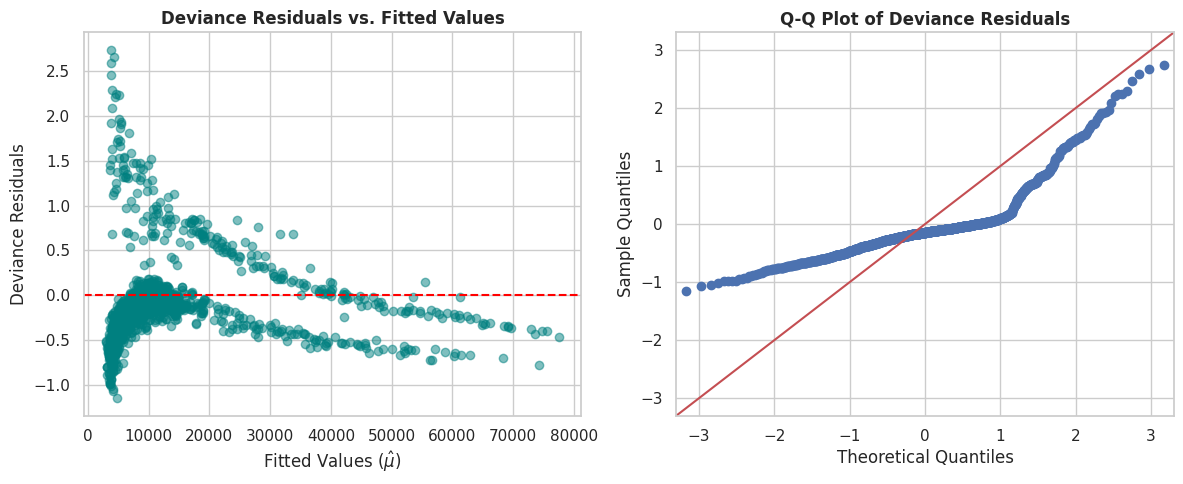

In [18]:
deviance_residuals = model_gamma.resid_deviance
fitted_values = model_gamma.fittedvalues

plt.figure(figsize=(12, 5))

# (1) Residuals vs Fitted Plot
plt.subplot(1, 2, 1)
plt.scatter(fitted_values, deviance_residuals, alpha=0.5, color='teal')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Deviance Residuals vs. Fitted Values', fontsize=12, fontweight='bold')
plt.xlabel('Fitted Values ($\hat{\mu}$)')
plt.ylabel('Deviance Residuals')

# (2) Q-Q Plot of Residuals
plt.subplot(1, 2, 2)
sm.qqplot(deviance_residuals, line='45', ax=plt.gca())
plt.title('Q-Q Plot of Deviance Residuals', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

精算費率相對數表 (Ratebook & Relativity)

In [ ]:
# 抓取模型參數與 p-value
coef = model_gamma.params
pvalues = model_gamma.pvalues
conf_int = model_gamma.conf_int()

ratebook = pd.DataFrame({
    'Beta Coefficient (coef)': coef,
    'Relativity (exp(coef))': np.exp(coef),
    'p-value': pvalues,
    'Lower 95% CI': np.exp(conf_int[0]),
    'Upper 95% CI': np.exp(conf_int[1])
})

# 格式化輸出
ratebook['Relativity (exp(coef))'] = ratebook['Relativity (exp(coef))'].round(4)
ratebook['p-value'] = ratebook['p-value'].round(4)
ratebook['Impact Description'] = [
    f"Base Premium (Intercept): ${np.exp(coef['Intercept']):.2f}",
    f"Northwest vs Base: {(np.exp(coef['C(region)[T.northwest]'])-1)*100:.1f}%",
    f"Southeast vs Base: {(np.exp(coef['C(region)[T.southeast]'])-1)*100:.1f}%",
    f"Southwest vs Base: {(np.exp(coef['C(region)[T.southwest]'])-1)*100:.1f}%",
    f"Per +1 Age: +{(np.exp(coef['age'])-1)*100:.1f}%",
    f"Per +1 BMI: +{(np.exp(coef['bmi'])-1)*100:.1f}%",
    f"Smoker Multiple: {np.exp(coef['is_smoker']):.2f}x",
    f"Per +1 Child: +{(np.exp(coef['children'])-1)*100:.1f}%"
]

print("=== 精算費率相對數表 (Actuarial Ratebook) ===")
print(ratebook[['Relativity (exp(coef))', 'p-value', 'Impact Description']])

定價計算器 (Pricing Function)

In [ ]:
def calculate_pure_premium(age, bmi, is_smoker, children, region, model=model_gamma):
    """
    輸入保戶特徵，計算 Gamma GLM 下的預期純保費 (Pure Premium)
    """
    # 建立輸入資料的 DataFrame
    input_data = pd.DataFrame({
        'age': [age],
        'bmi': [bmi],
        'is_smoker': [is_smoker],
        'children': [children],
        'region': [region]
    })

    # 預測預期理賠金額 (Pure Premium)
    predicted_premium = model.predict(input_data)[0]

    print(f"--- 保戶風險評估與費率試算 ---")
    print(f"保戶條件: {age}歲 | BMI {bmi} | 抽菸: {bool(is_smoker)} | 子女: {children}人 | 地區: {region}")
    print(f"預估純保費 (Pure Premium): ${predicted_premium:,.2f}")

    return predicted_premium

In [ ]:
# 測試 Pricing Function
sample_premium = calculate_pure_premium(
    age=35,
    bmi=28.5,
    is_smoker=1,
    children=2,
    region='southeast'
)

1. EDA 的精算解釋
 * 我們可以看到 claim_amount 呈現顯著的右偏（Right-skewed），且恆為正數。若使用傳統 OLS，常態分布假設會失靈，且可能預測出負的理賠金額；因此採用 Gamma GLM + Log Link，能完美搭配乘法結構並確保預測值為正。」
 * 「從散佈圖可發現，當 is_smoker = yes 且 BMI > 30 時，理賠金額有爆發性增長，這提示了風險因子之間存在顯著的交互作用。」
2. 模型診斷的解讀：
  * 「Deviance Residuals vs. Fitted Values 圖中，殘差大致勻稱分布在 $y=0$ 水平線兩側，沒有明顯的喇叭口（Heteroscedasticity）或曲線趨勢，說明模型假設合理。」
  * 「Q-Q Plot 在兩端微幅偏離，但整體呈直線，代表 Gamma 分配成功捕獲了極端賠案的尾部風險。」
3. 費率相對數（Relativity）與定價應用：
  * 「我們將 Log Link 下的 $\beta$ 係數取 $e^\beta$，轉化為精算定價用的 Relativity：
    * 基準保費 (Base)：約 $\$1,583$（Intercept 還原）。
    * 吸菸 (Smoker)：相對數為 $4.45$，即抽菸者需承受約 4.45 倍的風險加價。
    * 年齡與子女數：每多一歲保費增長 $+2.9\%$，每多一位子女增長 $+8.7\%$。」